In [1]:
""" applying linear regression to a real world problem"""
"""predicting medical expenses using linear regression"""
import pandas as pd
import numpy as np
import matplotlib as plt


In [2]:
"""QUESTION: ACME Insurance Inc. offers affordable health insurance to thousands of customer all over the United States. 
As the lead data scientist at ACME, you're tasked with creating an automated system to estimate the annual medical expenditure 
for new customers, using information such as their age, sex, BMI, children, smoking habits and region of residence.
Estimates from your system will be used to determine the annual insurance premium (amount paid every month) offered to the customer. 
Due to regulatory requirements, you must be able to explain why your system outputs a certain prediction.
You're given a CSV file containing verified historical data, consisting of the aforementioned information and the actual medical 
charges incurred by over 1300 customers."""

"QUESTION: ACME Insurance Inc. offers affordable health insurance to thousands of customer all over the United States. \nAs the lead data scientist at ACME, you're tasked with creating an automated system to estimate the annual medical expenditure \nfor new customers, using information such as their age, sex, BMI, children, smoking habits and region of residence.\nEstimates from your system will be used to determine the annual insurance premium (amount paid every month) offered to the customer. \nDue to regulatory requirements, you must be able to explain why your system outputs a certain prediction.\nYou're given a CSV file containing verified historical data, consisting of the aforementioned information and the actual medical \ncharges incurred by over 1300 customers."

In [3]:
medical_df = pd.read_csv('medical.csv')

In [4]:
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [5]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
!pip install plotly
!pip install seaborn
%pip install plotly seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [8]:
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [9]:
sns.set_style('darkgrid')
plt.rcParams['font.size'] = 14
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.facecolor'] = '#00000000'

In [10]:
medical_df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [11]:
!pip install nbformat --upgrade

In [12]:
fig = px.histogram(medical_df, 
                   x='age', 
                   marginal='box', 
                   nbins=47, 
                   title='Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()

In [13]:
fig = px.histogram(medical_df, 
                   x='bmi', 
                   marginal='box', 
                   color_discrete_sequence=['red'], 
                   title='Distribution of BMI (Body Mass Index)')
fig.update_layout(bargap=0.1)
fig.show()

In [14]:
fig = px.histogram(medical_df, 
                   x='charges', 
                   marginal='box', 
                   color='smoker', 
                   color_discrete_sequence=['green', 'grey'], 
                   title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

In [15]:
medical_df.smoker.value_counts()


smoker
no     1064
yes     274
Name: count, dtype: int64

In [16]:
px.histogram(medical_df, x='smoker', color='sex', title='Smoker')


In [17]:
fig = px.scatter(medical_df, 
                 x='age', 
                 y='charges', 
                 color='smoker', 
                 opacity=0.8, 
                 hover_data=['sex'], 
                 title='Age vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

In [18]:
fig = px.scatter(medical_df, 
                 x='bmi', 
                 y='charges', 
                 color='smoker', 
                 opacity=0.8, 
                 hover_data=['sex'], 
                 title='BMI vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

In [19]:
px.violin(medical_df, x = 'children',y = 'charges')

In [20]:
medical_df.charges.corr(medical_df.age)

np.float64(0.29900819333064754)

In [21]:
medical_df.charges.corr(medical_df.bmi)
smoker_values = {'no': 0, 'yes': 1}
smoker_numeric = medical_df.smoker.map(smoker_values)
medical_df.charges.corr(smoker_numeric)

np.float64(0.7872514304984772)

In [22]:
smoker_values = {'no': 0, 'yes': 1}
smoker_numeric = medical_df.smoker.map(smoker_values)
medical_df.charges.corr(smoker_numeric)

np.float64(0.7872514304984772)

In [23]:
medical_df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In [24]:
medical_df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

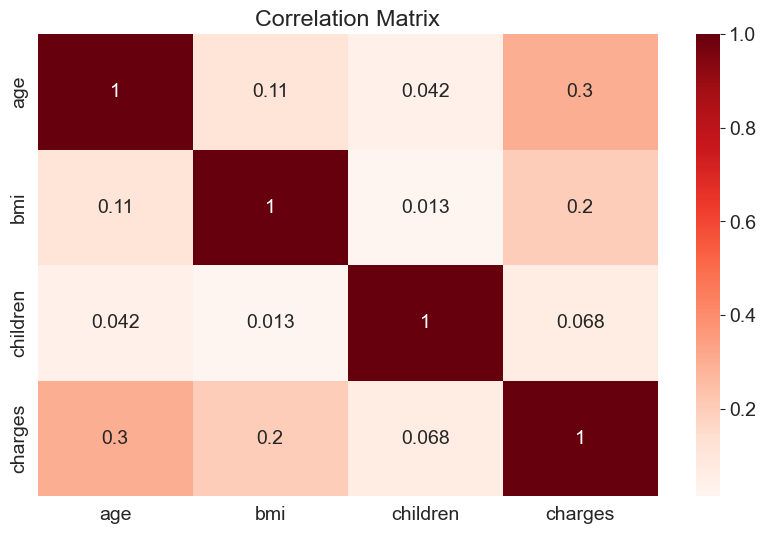

In [25]:
sns.heatmap(medical_df.corr(numeric_only=True), cmap='Reds', annot=True)
plt.title('Correlation Matrix')
plt.show()

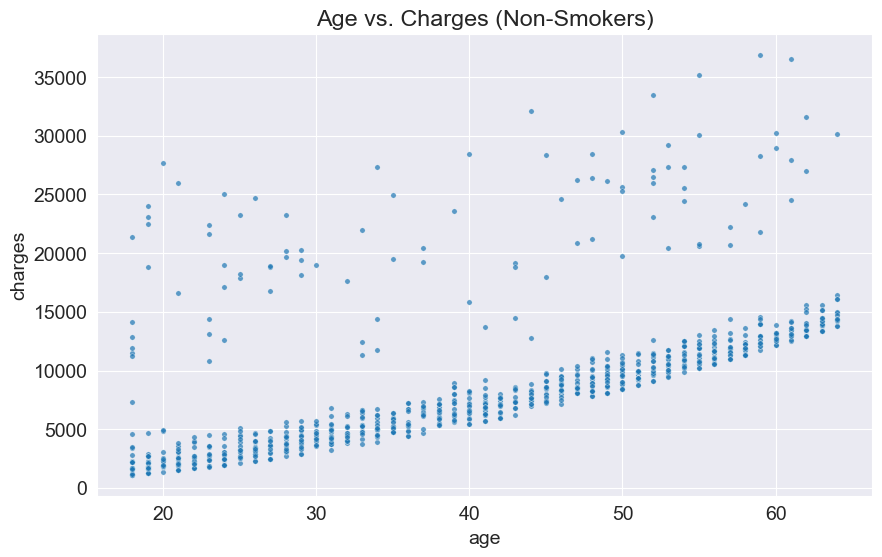

In [26]:
# Use the string 'no' instead of the number 0
non_smoker_df = medical_df[medical_df.smoker == 'no']

plt.title('Age vs. Charges (Non-Smokers)')
sns.scatterplot(data=non_smoker_df, x='age', y='charges', alpha=0.7, s=15)
plt.show()

In [27]:
def estimate_charges(age, w, b):
    return w * age + b

"""w = slope/weight and b = y-intercept/bias
weight and bias are ML and stats terms, whereas the others are just basic geometry"""

'w = slope/weight and b = y-intercept/bias\nweight and bias are ML and stats terms, whereas the others are just basic geometry'

In [28]:
w = 40
b = 100
estimate_charges(30,w,b)

1300

In [29]:
def estimate_charges(age, w, b):
    return w * age + b

w = 40
b = 100

estimate_charges(30, w, b)

ages = non_smoker_df.age
estimated_charges = estimate_charges(ages, w, b)
estimated_charges


1        820
2       1220
3       1420
4       1380
5       1340
        ... 
1332    2180
1333    2100
1334     820
1335     820
1336     940
Name: age, Length: 1064, dtype: int64

In [30]:
non_smoker_df.charges

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

In [31]:
ages = non_smoker_df.age
ages

1       18
2       28
3       33
4       32
5       31
        ..
1332    52
1333    50
1334    18
1335    18
1336    21
Name: age, Length: 1064, dtype: int64

In [32]:
non_smoker_df
medical_df.smoker.unique()

array(['yes', 'no'], dtype=object)

In [33]:
ages = non_smoker_df.age
estimated_charges = estimate_charges(ages, w, b)

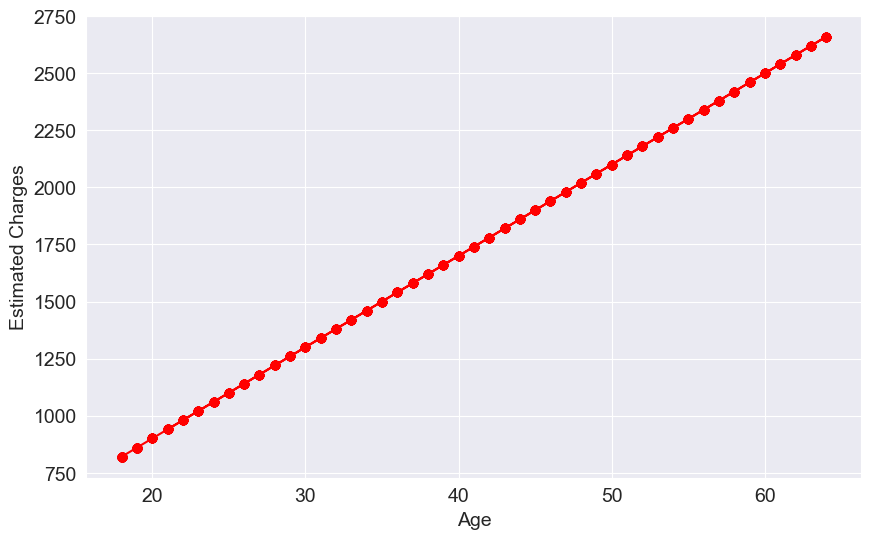

In [34]:
plt.plot(ages, estimated_charges, 'r-o');
plt.xlabel('Age');
plt.ylabel('Estimated Charges');

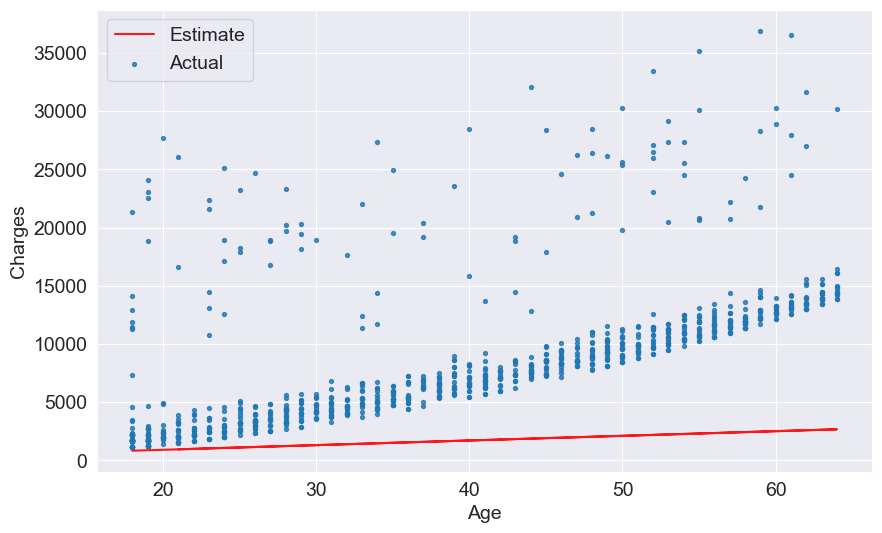

In [35]:
target = non_smoker_df.charges

plt.plot(ages, estimated_charges, 'r', alpha=0.9);
plt.scatter(ages, target, s=8,alpha=0.8);
plt.xlabel('Age');
plt.ylabel('Charges')
plt.legend(['Estimate', 'Actual']);

In [36]:
def try_parameters(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges
    
    estimated_charges = estimate_charges(ages, w, b)
    
    plt.plot(ages, estimated_charges, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual']);

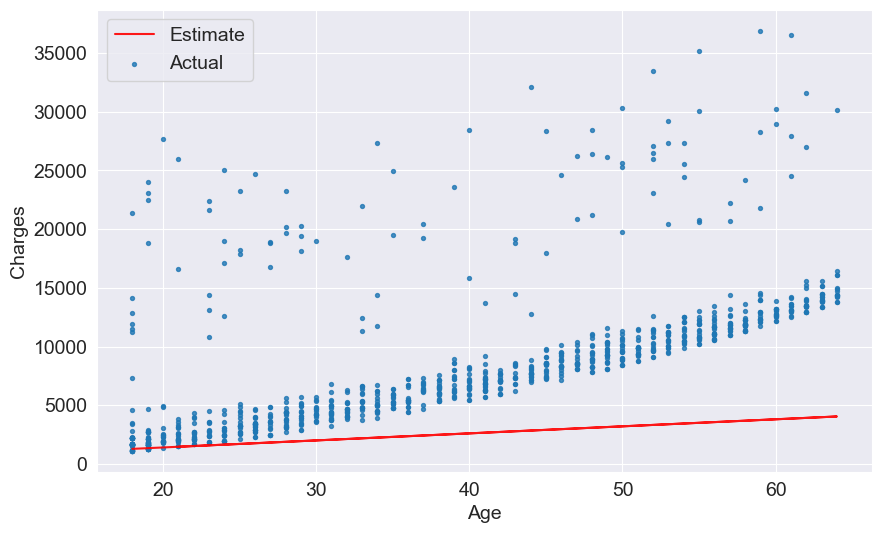

In [37]:
try_parameters(60, 200)

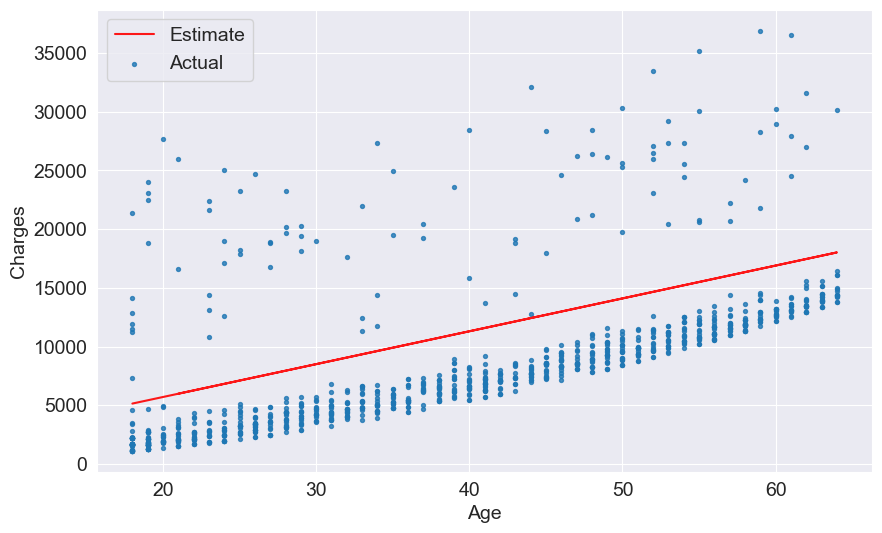

In [38]:
try_parameters(280, 100)

In [39]:
import numpy as np

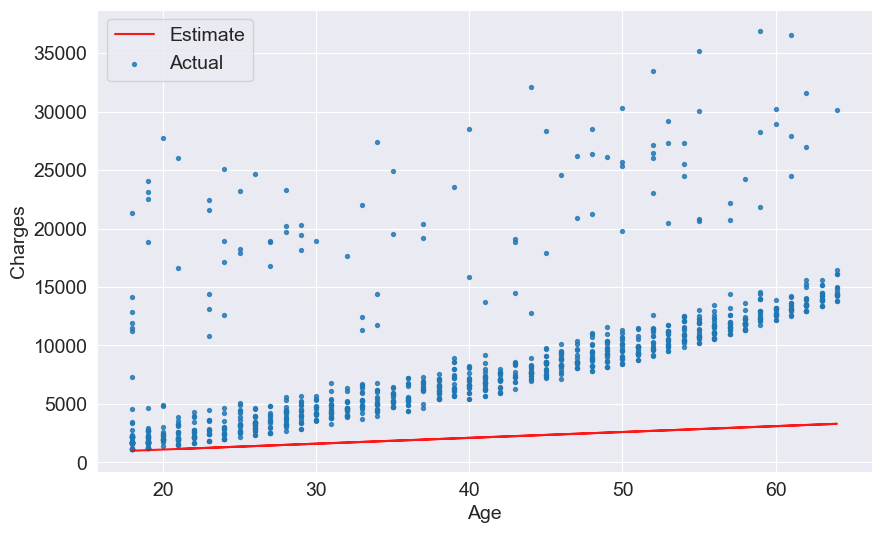

In [40]:
def rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))
w = 50
b = 100
try_parameters(w, b)

In [41]:
targets = non_smoker_df['charges']
predicted = estimate_charges(non_smoker_df.age, w, b)

In [42]:
rmse(targets, predicted)

np.float64(8461.949562575493)

In [43]:
def try_parameters(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges
    predictions = estimate_charges(ages, w, b)
    
    plt.plot(ages, predictions, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Prediction', 'Actual']);
    
    loss = rmse(target, predictions)
    print("RMSE Loss: ", loss)

RMSE Loss:  8461.949562575493


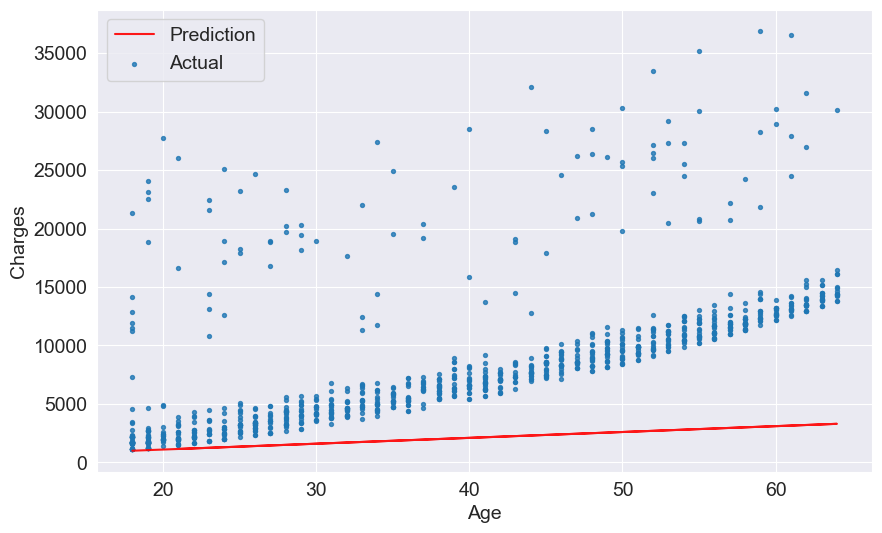

In [44]:
try_parameters(50, 100)

RMSE Loss:  4991.993804156943


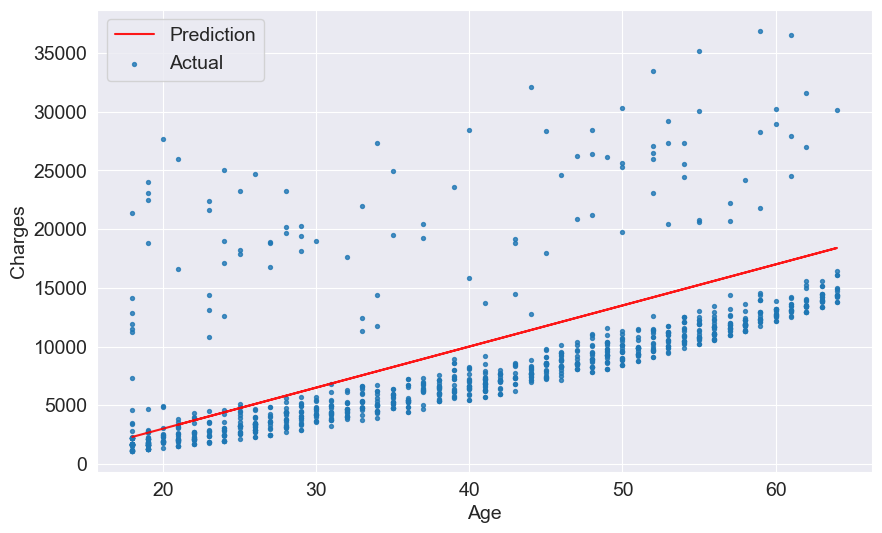

In [45]:
try_parameters(350, -4000)

In [46]:
!pip install scikit-learn --quiet
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [47]:
help(model.fit)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.

    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.

    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.

        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.

    Returns
    -------
    self : object
        Fitted Estimator.



In [48]:
inputs = non_smoker_df[['age']]
targets = non_smoker_df.charges
print('inputs.shape :', inputs.shape)
print('targes.shape :', targets.shape)

inputs.shape : (1064, 1)
targes.shape : (1064,)


In [49]:
model.fit(inputs, targets)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [50]:
model.predict(np.array([[23], 
                        [37], 
                        [61]]))

/Users/aditijha/Desktop/ML/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 4055.30443855,  7796.78921819, 14210.76312614])

In [51]:
predictions = model.predict(inputs)

In [52]:
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289], shape=(1064,))

In [58]:
inputs
targets

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

In [53]:
rmse(targets, predictions)

np.float64(4662.505766636395)

In [54]:
# w
model.coef_

array([267.24891283])

In [55]:
# b
model.intercept_

np.float64(-2091.4205565650773)

RMSE Loss:  4662.505766636395


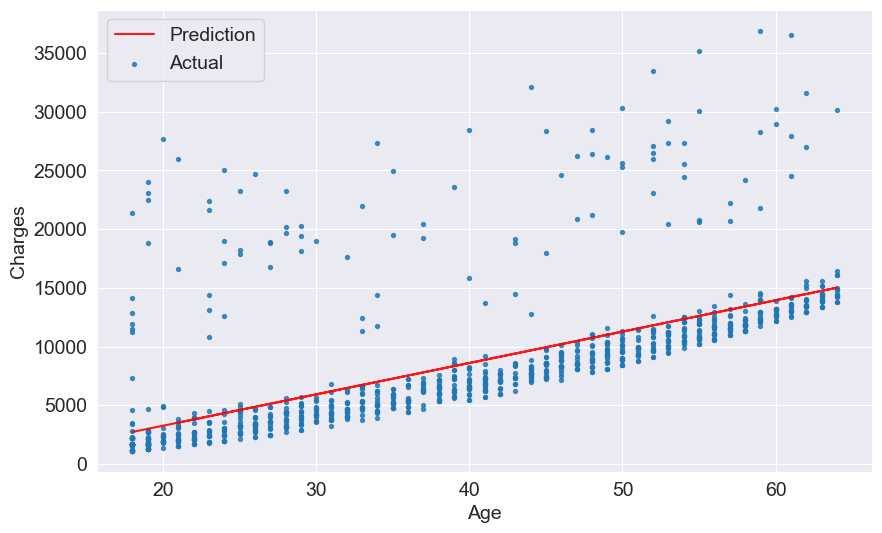

In [56]:
try_parameters(model.coef_, model.intercept_)